# Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Naive-Bayes-Classification-Data.csv')
df.head()

,glucose,bloodpressure,diabetes
0,40,85,0
1,40,92,0
2,45,63,1
3,45,80,0
4,40,73,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   glucose        995 non-null    int64
 1   bloodpressure  995 non-null    int64
 2   diabetes       995 non-null    int64
dtypes: int64(3)
memory usage: 23.4 KB


# Data Balancing

In [4]:
df['diabetes'].value_counts()

diabetes
1    498
0    497
Name: count, dtype: int64

Karena jumlah data pada label 1 dan 0 hanya berbeda 1 data saja, maka tidak perlu dilakukan data balancing.

In [5]:
# Jika perlu dilakukan data balancing bisa dilakukan seperti ini
major = df[df['diabetes'] == 1]
minor = df[df['diabetes'] == 0]
major_undersample = major.sample(n=len(minor), random_state=42)
df = pd.concat([major_undersample, minor])
df['diabetes'].value_counts()


diabetes
1    497
0    497
Name: count, dtype: int64

<Axes: >

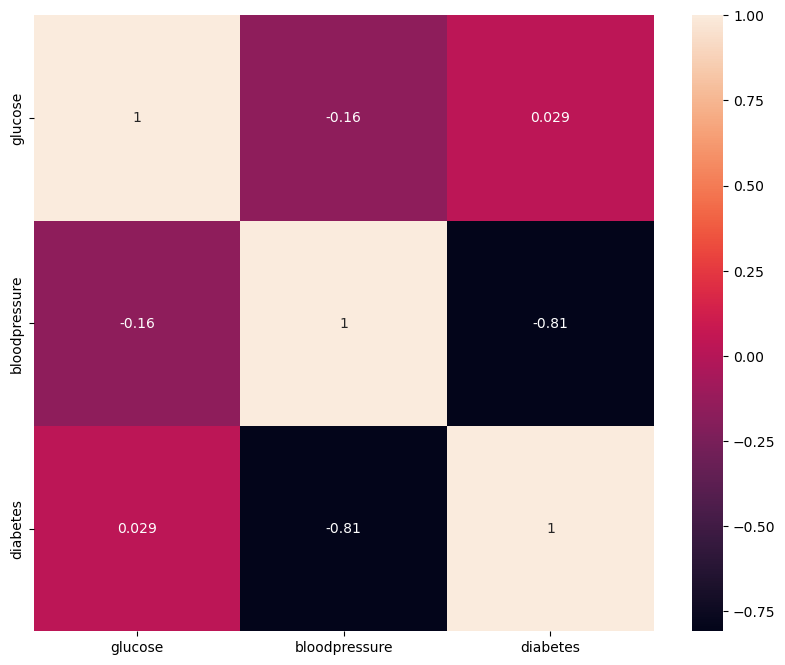

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)

# Data Cleaning

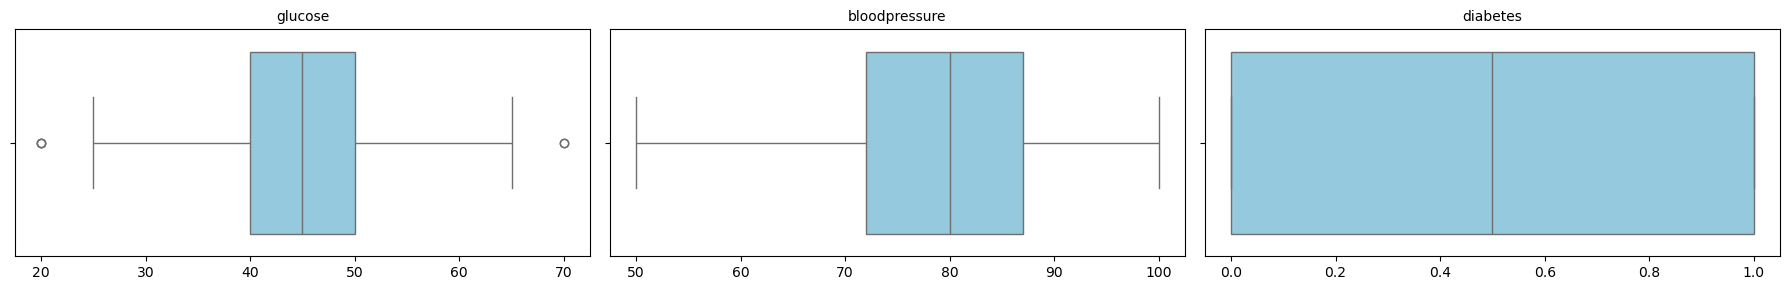

In [7]:
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_columns = len(kolom_numerik)
num_cols = 3
num_rows = (num_columns + num_cols - 1) // num_cols

plt.figure(figsize=(18, num_rows * 3))
for i, column in enumerate(kolom_numerik, 1):
    plt.subplot(num_rows, num_cols, i)
    sns.boxplot(x=df[column], orient='h', color='skyblue')
    plt.title(column, fontsize=10)
    plt.xlabel("")

plt.tight_layout()
plt.show()

In [8]:
def bersihkan_outlier(df, kolom, metode='zscore', threshold=3):
    if metode == 'zscore':
        # Metode Z-score
        z_scores = np.abs((df[kolom] - df[kolom].mean()) / df[kolom].std())
        return df[z_scores < threshold]

    elif metode == 'iqr':
        # Metode IQR (Interquartile Range)
        Q1 = df[kolom].quantile(0.25)
        Q3 = df[kolom].quantile(0.75)
        IQR = Q3 - Q1

        batas_bawah = Q1 - threshold * IQR
        batas_atas = Q3 + threshold * IQR

        return df[(df[kolom] >= batas_bawah) & (df[kolom] <= batas_atas)]

df = bersihkan_outlier(df, kolom_numerik, metode='iqr', threshold=1.5)
df.head()

,glucose,bloodpressure,diabetes
973,60.0,63,1
158,40.0,73,1
471,35.0,70,1
354,40.0,63,1
480,45.0,78,1


In [9]:
df.isnull().sum()

glucose          5
bloodpressure    0
diabetes         0
dtype: int64

In [10]:
df.dropna(inplace=True)

# Modeling

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [12]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('diabetes', axis=1), df['diabetes'], test_size=0.2, random_state=42)


In [13]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [14]:
y_pred = model.predict(X_test)

# Evaluation Model

In [15]:
print("Accuracy Score", accuracy_score(y_test, y_pred))

Accuracy Score 0.9494949494949495


In [16]:
print('Classification Report')
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       105
           1       0.95      0.95      0.95        93

    accuracy                           0.95       198
   macro avg       0.95      0.95      0.95       198
weighted avg       0.95      0.95      0.95       198



In [17]:
print('Confusion Matrix')
print(confusion_matrix(y_test, y_pred))

Confusion Matrix
[[100   5]
 [  5  88]]


In [18]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
model_naive = sm.Logit(y_train, X_train_sm)
result = model_naive.fit()

Optimization terminated successfully.
         Current function value: 0.195294
         Iterations 9


In [19]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:               diabetes   No. Observations:                  791
Model:                          Logit   Df Residuals:                      788
Method:                           MLE   Df Model:                            2
Date:                Fri, 09 May 2025   Pseudo R-squ.:                  0.7182
Time:                        16:01:32   Log-Likelihood:                -154.48
converged:                       True   LL-Null:                       -548.25
Covariance Type:            nonrobust   LLR p-value:                9.715e-172
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            46.5833      3.790     12.291      0.000      39.155      54.012
glucose          -0.0986      0.025     -3.943      0.000      -0.148      -0.050
bloodpressure    -0.5284      0.041    -

In [20]:
print('p-value', result.pvalues)


p-value const            1.016552e-34
glucose          8.034590e-05
bloodpressure    2.808995e-38
dtype: float64


In [21]:
print('coefficients', result.params)

coefficients const            46.583347
glucose          -0.098644
bloodpressure    -0.528443
dtype: float64


In [22]:
from sklearn.metrics import roc_curve, auc, roc_auc_score


In [23]:
y_proba = result.predict(sm.add_constant(X_test))
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

In [24]:
print('ROC AUC Score:', roc_auc)

ROC AUC Score: 0.973783922171019


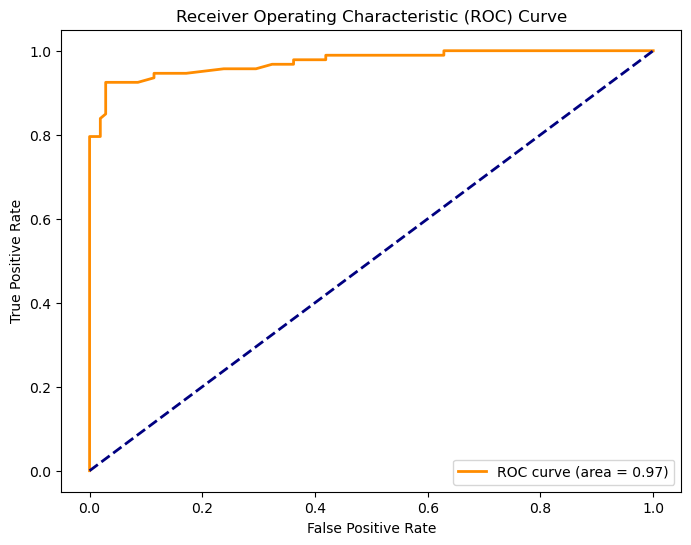

In [25]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

### Load Model

In [26]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

In [27]:
!pip install pyngrok

In [28]:
!ngrok authtoken add-authtoken USE YOUR OWN AUTHTOKEN

ERROR:  accepts 1 arg(s), received 5


In [29]:
!pip install streamlit

In [30]:
import streamlit as st

In [31]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import roc_curve, auc
import plotly.express as px
import plotly.graph_objects as go

st.set_page_config(
    page_title="Dashboard Prediksi Diabetes",
    page_icon="🩺",
    layout="wide"
)

def clear_outlier(df, kolom_numerik, metode='iqr', threshold=1.5):
    # Metode IQR (Interquartile Range)
    Q1 = df[kolom_numerik].quantile(0.25)
    Q3 = df[kolom_numerik].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - threshold * IQR
    batas_atas = Q3 + threshold * IQR

    return df[(df[kolom_numerik] >= batas_bawah) & (df[kolom_numerik] <= batas_atas)]

# Fungsi untuk memuat data
@st.cache_data
def load_data():
    df = pd.read_csv('Naive-Bayes-Classification-Data.csv')
    # Membersihkan outlier
    kolom_numerik = ['glucose', 'bloodpressure']
    for kolom in kolom_numerik:
        df = clear_outlier(df, kolom)
    df.dropna(inplace=True)
    return df

# Fungsi untuk memuat model
@st.cache_resource
def load_model():
    return joblib.load('model.pkl')

# Fungsi untuk membuat grafik ROC
def plot_roc_curve(model, X, y):
    y_prob = model.predict_proba(X)[:, 1]
    
    # Menghitung nilai ROC
    fpr, tpr, thresholds = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # Membuat grafik ROC
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=fpr, 
            y=tpr,
            mode='lines',
            line=dict(color='#e74c3c', width=2),
            name=f'ROC Curve (AUC = {roc_auc:.2f})'
        )
    )
    
    # Menambahkan garis diagonal
    fig.add_trace(
        go.Scatter(
            x=[0, 1], 
            y=[0, 1],
            mode='lines',
            line=dict(color='navy', width=2, dash='dash'),
            name='Random Chance'
        )
    )
    
    fig.update_layout(
        title='Kurva ROC',
        xaxis=dict(title='False Positive Rate'),
        yaxis=dict(title='True Positive Rate'),
        legend=dict(x=0.7, y=0.05),
        width=700,
        height=500
    )
    
    return fig

# Fungsi untuk memberikan rekomendasi berdasarkan hasil prediksi
def get_recommendation(prediction, probability, glucose, bloodpressure):
    if prediction == 1:
        if probability > 0.8:
            return """
            ### Rekomendasi Tindakan: Risiko Tinggi Diabetes
            
            Berdasarkan hasil prediksi, Anda memiliki risiko tinggi diabetes. Rekomendasi tindakan:
            
            1. **Segera Konsultasi dengan Dokter**: Lakukan pemeriksaan gula darah lengkap
            2. **Evaluasi Pola Makan**: Kurangi konsumsi karbohidrat sederhana dan gula
            3. **Tingkatkan Aktivitas Fisik**: Lakukan olahraga teratur minimal 150 menit per minggu
            4. **Pantau Tekanan Darah**: Lakukan pemeriksaan tekanan darah secara rutin
            5. **Jaga Berat Badan Ideal**: Turunkan berat badan jika berlebih
            """
        else:
            return """
            ### Rekomendasi Tindakan: Risiko Sedang Diabetes
            
            Berdasarkan hasil prediksi, Anda memiliki risiko sedang diabetes. Rekomendasi tindakan:
            
            1. **Konsultasi dengan Dokter**: Lakukan pemeriksaan gula darah
            2. **Perhatikan Pola Makan**: Batasi konsumsi makanan tinggi gula dan karbohidrat olahan
            3. **Rutin Berolahraga**: Minimal 30 menit per hari, 5 kali seminggu
            4. **Pantau Tekanan Darah**: Pertahankan tekanan darah normal
            5. **Hindari Stres Berlebih**: Kelola stres dengan baik
            """
    else:
        if glucose > 50 or bloodpressure > 80:
            return """
            ### Rekomendasi Tindakan: Risiko Rendah Diabetes
            
            Berdasarkan hasil prediksi, Anda memiliki risiko rendah diabetes. Namun, beberapa nilai parameter Anda perlu diperhatikan. Rekomendasi tindakan:
            
            1. **Pemeriksaan Rutin**: Lakukan pemeriksaan gula darah setahun sekali
            2. **Pertahankan Pola Makan Sehat**: Konsumsi makanan seimbang dengan banyak serat
            3. **Jaga Aktivitas Fisik**: Tetap aktif secara fisik
            4. **Pantau Tekanan Darah**: Periksa tekanan darah secara berkala
            """
        else:
            return """
            ### Rekomendasi Tindakan: Risiko Sangat Rendah Diabetes
            
            Berdasarkan hasil prediksi, Anda memiliki risiko sangat rendah diabetes. Rekomendasi tindakan:
            
            1. **Pertahankan Gaya Hidup Sehat**: Lanjutkan pola makan seimbang dan aktivitas fisik
            2. **Pemeriksaan Berkala**: Lakukan pemeriksaan kesehatan umum secara berkala
            3. **Edukasi Diri**: Tetap update informasi tentang pencegahan diabetes
            """

# Memuat data dan model
df = load_data()
model = load_model()

# Header
st.title("Dashboard Prediksi Diabetes Berdasarkan Tekanan Darah dan Kadar Glukosa")

# Overview Dashboardnya
st.markdown("""
## Selamat Datang di Dashboard Prediksi Diabetes

Dashboard ini menggunakan model Naive Bayes untuk memprediksi kemungkinan diabetes berdasarkan kadar glukosa dan tekanan darah.

### Dataset:
Dataset berisi informasi tentang kadar glukosa, tekanan darah, dan status diabetes (0: Tidak diabetes, 1: Diabetes).
""")

# Tampilkan beberapa statistik dasar
col1, col2, col3 = st.columns(3)
with col1:
    st.metric("Jumlah Data", df.shape[0])
with col2:
    st.metric("Pasien Diabetes", df[df['diabetes'] == 1].shape[0])
with col3:
    st.metric("Pasien Non-Diabetes", df[df['diabetes'] == 0].shape[0])

# Distribusi kelas
st.subheader("Distribusi Status Diabetes dalam Dataset")
fig = px.pie(df, names='diabetes', title='Distribusi Status Diabetes', 
             color_discrete_sequence=['#3498db', '#e74c3c'],
             labels={'0':'Tidak Diabetes', '1':'Diabetes'})
st.plotly_chart(fig)

# Form untuk input data baru
st.markdown("---")
st.subheader("Prediksi Diabetes untuk Data Baru")

col1, col2 = st.columns(2)
with col1:
    glucose = st.number_input("Kadar Glukosa", min_value=int(df['glucose'].min()), max_value=int(df['glucose'].max()), value=int(df['glucose'].mean()))
with col2:
    bloodpressure = st.number_input("Tekanan Darah", min_value=int(df['bloodpressure'].min()), max_value=int(df['bloodpressure'].max()), value=int(df['bloodpressure'].mean()))

# Prediksi
if st.button("Prediksi", type="primary"):
    input_data = pd.DataFrame([[glucose, bloodpressure]], columns=['glucose', 'bloodpressure'])
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0]
    
    # Tampilkan hasil
    st.markdown("---")
    st.subheader("Hasil Prediksi")
    
    if prediction == 1:
        st.error(f"Prediksi: **Diabetes** dengan probabilitas {probability[1]:.2%}")
    else:
        st.success(f"Prediksi: **Tidak Diabetes** dengan probabilitas {probability[0]:.2%}")
    
    # Visualisasi probabilitas
    col1, col2 = st.columns(2)
    
    with col1:
        # Grafik probabilitas
        fig = go.Figure()
        fig.add_trace(go.Bar(
            x=['Tidak Diabetes', 'Diabetes'],
            y=[probability[0], probability[1]],
            marker_color=['#3498db', '#e74c3c']
        ))
        fig.update_layout(
            title='Probabilitas Prediksi',
            yaxis=dict(title='Probabilitas', range=[0, 1]),
            xaxis=dict(title='Kelas')
        )
        st.plotly_chart(fig)
    
    with col2:
        # Grafik ROC
        X = df.drop('diabetes', axis=1)
        y = df['diabetes']
        roc_fig = plot_roc_curve(model, X, y)
        st.plotly_chart(roc_fig)
    
    # Tampilkan rekomendasi
    st.markdown(get_recommendation(prediction, probability[prediction], glucose, bloodpressure))

# Footer
st.markdown("---")

Writing app.py


In [34]:
from pyngrok import ngrok, conf
import threading
import os
def run_streamlit():
  os.system("streamlit run app.py --server.port 8501")
thread = threading.Thread(target=run_streamlit)
thread.start()

public_url = ngrok.connect(addr='8501')
print(public_url)

NgrokTunnel: "https://d37b-36-69-141-121.ngrok-free.app" -> "http://localhost:8501"
